In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, print_wise, get_lagplot, compatible_TimeSeries_check
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.general_utils.regression import dyn_linear_encoding
from useful_stuff.general_utils.II import dynInformationImbalance
from project_specific_utils.dataloader import load_meg_data, load_concat_regressout_meg, load_concat_regressout_mod
from image_processing.gaze_dep_models import save_ANN_features
from analyses.subsampling_lagged_comparisons import save_lagged_comparisons, get_spaced_pseudotrials


In [2]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    gaze_fs = 50
    mod_fs = 23.976
    model_name = "vit_l_16";
    layer_name = "classifier.2";
    n_components = 1000
    pooling = "all"
    sq_side = 384
    repetition = 0
    downsampled_sq_size = 50
    sensors_group = 'occ'
    time_points = 50
    regress_out_gaze = "PCR"
    PCs_to_regress_out = 50
    timepts_to_regress_out = 50
    max_lag=100
    pkg="timm"
    analysis_type = "encoding"
    regression_type = "ridge"
    score_type = "corr"
    n_model_components = 1000
    model_PCs_to_keep = 50

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)

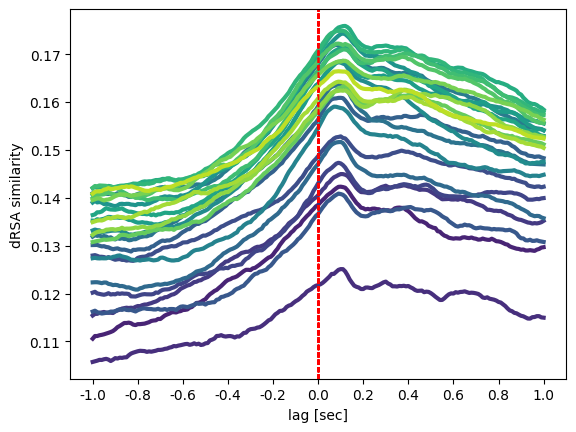

In [93]:
from useful_stuff.general_utils.plots import truncate_colormap
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, 24))
lagplots = []
centroids = []
peaks = []
tick_step = 20
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
for i in range(24):
    s = loadmat(f"/Users/tizianocausin/1917_local/results/encoding_sub003_occ_rep0_dino_v3_l_layer.{i}.mlp.down_proj_50PCs_ridge_corr_lag_1s_384x384patch_regr_out_gaze_PCR.mat")
    # print(s["encoding"].shape)
    lagplot =np.squeeze(s["encoding"])
    lagplots.append(lagplot)
    # --- compute peak ---
    peak_idx = np.argmax(lagplot)
    lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)

    weights = lagplot.copy()
    weights[weights < 0] = 0  # optional but recommended

    centroid = np.sum(lags * weights) / np.sum(weights)
    centroid_lag = np.round(centroid / cfg.neu_fs, 2)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - cfg.max_lag) / cfg.neu_fs  # convert to seconds
    peaks.append(peak_lag)
    centroids.append(centroid_lag)
    plt.plot(lagplot, linewidth=3, label=f"Block {i} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[i])
    plt.ylabel("dRSA similarity")
    plt.xlabel("lag [sec]")
    plt.xticks(ticks, ticks_labels)
    plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)



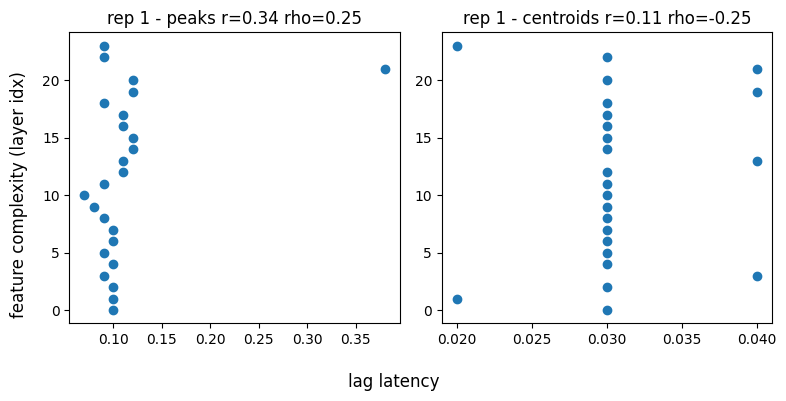

In [94]:
from useful_stuff.general_utils.utils import spearman
max_lag = 200
tick_step = 40
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
rho = np.round(spearman(np.arange(len(peaks)), np.array(peaks)),2)
r = round(np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1],2)
ax[0].set_title(f"rep {cfg.repetition+1} - peaks r={r} rho={rho}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearman(np.arange(len(peaks)), np.array(centroids)), 2)
r = round(np.corrcoef(np.arange(len(centroids)), np.array(centroids))[0,1],2)
ax[1].set_title(f"rep {cfg.repetition+1} - centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()